# Notebook 08 — XGBoost + LightGBM + Optuna Hyperparameter Tuning

**Inputs:** `outputs/train.parquet`, `outputs/val.parquet`, `outputs/test.parquet`, `outputs/model_comparison.csv`  
**Outputs:** `outputs/xgb_model.pkl`, `outputs/lgbm_model.pkl`, `outputs/optuna_xgb_study.pkl`, `outputs/optuna_lgbm_study.pkl`

**Fixes applied vs prompt template:**
- `XGBClassifier(**params)` — prompt had incorrect positional dict arg
- `LGBMClassifier(**params)` — same fix
- Added `metric='auc'` to LightGBM params so early stopping optimises the same metric as Optuna
- `scale_pos_weight` computed from **train set only** (no val/test leakage)
- Optuna verbosity suppressed; LightGBM verbosity suppressed
- Column names cleaned at load time (spaces → `_`, hyphens → `_`)
- Tree models use **raw (unscaled) features** — scaling is invariant to monotone transforms
- Final refit on train+val uses **fixed n_estimators** (no early stopping — no held-out val remains)
- Val metrics computed separately for a fair 4-model comparison table

In [1]:
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import lightgbm as lgb
from pathlib import Path
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, classification_report
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT    = Path("..").resolve()
OUTPUTS = ROOT / "outputs"

cw_text = (OUTPUTS / "class_weight_ratio.txt").read_text()
# loaded only for reference — we recompute from train below
global_cw_ratio = float(
    next(l for l in cw_text.splitlines() if l.startswith("class_weight_ratio=")).split("=")[1]
)
print("Global class_weight_ratio (reference):", round(global_cw_ratio, 4))

Global class_weight_ratio (reference): 10.1183


In [2]:
def load_split(path):
    """Load parquet, normalise column names (spaces/hyphens → underscores)."""
    df = pd.read_parquet(path)
    df.columns = [c.replace(" ", "_").replace("-", "_") for c in df.columns]
    return df

train = load_split(OUTPUTS / "train.parquet")
val   = load_split(OUTPUTS / "val.parquet")
test  = load_split(OUTPUTS / "test.parquet")

TARGET       = "is_churn"
FEATURE_COLS = [c for c in train.columns if c not in ("msno", TARGET)]

X_train = train[FEATURE_COLS].values.astype(np.float32)
y_train = train[TARGET].values
X_val   = val[FEATURE_COLS].values.astype(np.float32)
y_val   = val[TARGET].values
X_test  = test[FEATURE_COLS].values.astype(np.float32)
y_test  = test[TARGET].values

# Compute scale_pos_weight from TRAIN only — prevents val/test leakage into imbalance handling
n_neg_train = int((y_train == 0).sum())
n_pos_train = int((y_train == 1).sum())
scale_pos_weight = n_neg_train / n_pos_train

print("Train : %s rows | neg=%s pos=%s | scale_pos_weight=%.4f" % (
    f"{len(X_train):,}", f"{n_neg_train:,}", f"{n_pos_train:,}", scale_pos_weight))
print("Val   : %s rows | churn=%.2f%%" % (f"{len(X_val):,}",  y_val.mean()*100))
print("Test  : %s rows | churn=%.2f%%" % (f"{len(X_test):,}", y_test.mean()*100))
print("Features (%d): %s" % (len(FEATURE_COLS), FEATURE_COLS))

Train : 742,546 rows | neg=676,319 pos=66,227 | scale_pos_weight=10.2121
Val   : 103,142 rows | churn=9.81%
Test  : 125,272 rows | churn=8.77%
Features (35): ['total_paid', 'avg_payment', 'max_payment', 'discount_rate', 'n_transactions', 'avg_plan_days', 'auto_renew_rate', 'cancel_rate', 'days_as_member', 'n_payment_methods', 'total_secs', 'avg_daily_secs', 'max_daily_secs', 'total_songs_played', 'completion_rate', 'skip_rate', 'unique_songs_ratio', 'active_days', 'days_since_last_log', 'city_freq_rank', 'age', 'membership_tenure', 'gender_male', 'gender_female', 'gender_unknown', 'reg_via_4', 'reg_via_3', 'reg_via_9', 'reg_via_7', 'reg_via_11', 'reg_via_other', 'segment_At_Risk', 'segment_Casual_Listeners', 'segment_Dormant', 'segment_Power_Users']


## Section 1 — XGBoost with Optuna

Val is used **only as an evaluation set** for early stopping — it is never passed to `fit()` as training data. No leakage.

In [3]:
def xgb_objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 200, 1000),
        "max_depth":          trial.suggest_int("max_depth", 3, 8),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight":   scale_pos_weight,   # train-only, no leakage
        "eval_metric":        "auc",
        "early_stopping_rounds": 30,
        "random_state":       42,
        "verbosity":          0,
    }
    # Fix from prompt: use **params (not positional dict)
    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

print("Running XGBoost Optuna study (50 trials)...")
t0 = time.time()
study_xgb = optuna.create_study(direction="maximize", study_name="xgb_churn")
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
xgb_study_time = time.time() - t0

print("\nXGBoost Optuna complete in %.1f min" % (xgb_study_time / 60))
print("Best val ROC-AUC : %.4f" % study_xgb.best_value)
print("Best params      :", study_xgb.best_params)

Running XGBoost Optuna study (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


XGBoost Optuna complete in 8.7 min
Best val ROC-AUC : 0.9815
Best params      : {'n_estimators': 413, 'max_depth': 8, 'learning_rate': 0.09063243761985919, 'subsample': 0.9412740335607451, 'colsample_bytree': 0.7589746620940012, 'min_child_weight': 7}


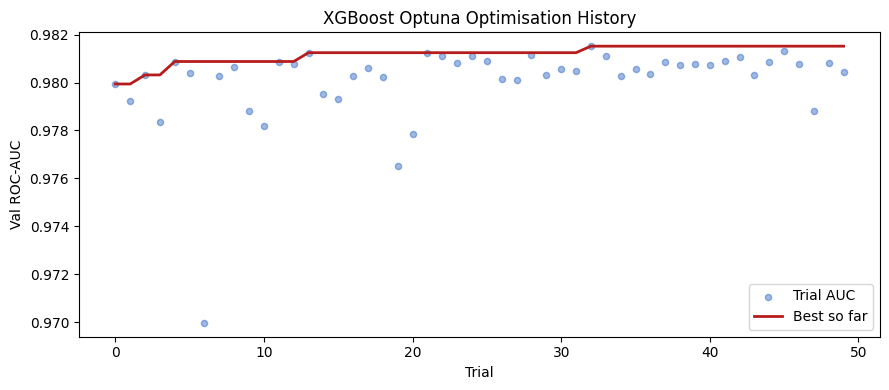

Saved: outputs/08_xgb_optuna_history.png


In [4]:
# Optuna optimisation history — matplotlib (no plotly dependency)
trial_values = [t.value for t in study_xgb.trials if t.value is not None]
best_so_far  = pd.Series(trial_values).cummax()

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(range(len(trial_values)), trial_values, alpha=0.4, s=20,
           color="#0F52BA", label="Trial AUC")
ax.plot(range(len(best_so_far)), best_so_far, color="#B71C1C",
        linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Val ROC-AUC")
ax.set_title("XGBoost Optuna Optimisation History")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "08_xgb_optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/08_xgb_optuna_history.png")

## Section 2 — LightGBM with Optuna

In [5]:
def lgbm_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":      1,
        "class_weight":      "balanced",  # computed from train set by LightGBM internally
        "metric":            "auc",       # early stopping optimises same metric as Optuna
        "verbosity":         -1,
        "random_state":      42,
    }
    # Fix from prompt: use **params (not positional dict)
    model = LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
    )
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

print("Running LightGBM Optuna study (50 trials)...")
t0 = time.time()
study_lgbm = optuna.create_study(direction="maximize", study_name="lgbm_churn")
study_lgbm.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)
lgbm_study_time = time.time() - t0

print("\nLightGBM Optuna complete in %.1f min" % (lgbm_study_time / 60))
print("Best val ROC-AUC : %.4f" % study_lgbm.best_value)
print("Best params      :", study_lgbm.best_params)

Running LightGBM Optuna study (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 rounds


Did not meet early stopping. Best iteration is:
[609]	valid_0's auc: 0.97873


Training until validation scores don't improve for 30 rounds


...

Training until validation scores don't improve for 30 rounds


Early stopping, best iteration is:
[751]	valid_0's auc: 0.979849


Training until validation scores don't improve for 30 rounds


Did not meet early stopping. Best iteration is:
[392]	valid_0's auc: 0.980087



LightGBM Optuna complete in 7.8 min
Best val ROC-AUC : 0.9818
Best params      : {'n_estimators': 540, 'num_leaves': 98, 'learning_rate': 0.08653948624452329, 'min_child_samples': 53, 'feature_fraction': 0.7080202400021893, 'bagging_fraction': 0.9977985318643916}


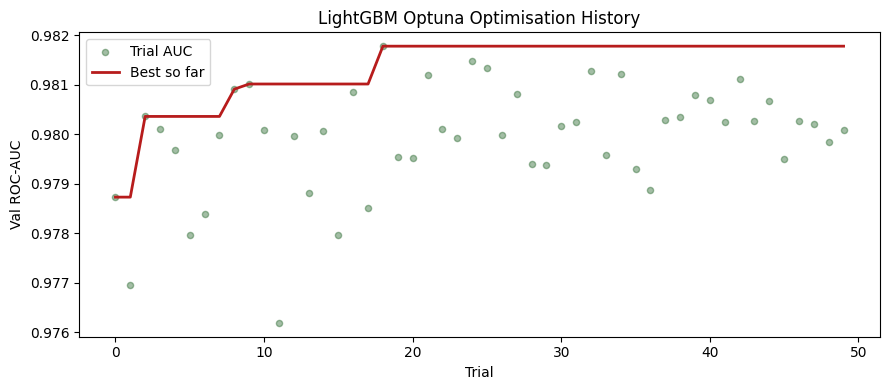

Saved: outputs/08_lgbm_optuna_history.png


In [6]:
# LightGBM optimisation history
lgbm_trial_values = [t.value for t in study_lgbm.trials if t.value is not None]
lgbm_best_so_far  = pd.Series(lgbm_trial_values).cummax()

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(range(len(lgbm_trial_values)), lgbm_trial_values, alpha=0.4, s=20,
           color="#1B5E20", label="Trial AUC")
ax.plot(range(len(lgbm_best_so_far)), lgbm_best_so_far, color="#B71C1C",
        linewidth=2, label="Best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Val ROC-AUC")
ax.set_title("LightGBM Optuna Optimisation History")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "08_lgbm_optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/08_lgbm_optuna_history.png")

## Section 3 — Refit Best Models

Two-step refit strategy:
1. **Val evaluation model**: refit on train only → predict on val → fair comparison with LR/RF  
2. **Final production model**: refit on train+val → evaluate on test (maximum data for deployment)

`early_stopping_rounds` is **removed** for both refits — there is no separate holdout for early stopping when training on all available labelled data.

In [7]:
# ── XGBoost ──────────────────────────────────────────────────────────────
xgb_best = study_xgb.best_params.copy()
xgb_refit_params = {
    k: v for k, v in xgb_best.items()
    if k not in ("early_stopping_rounds", "eval_metric")
}
xgb_refit_params.update({"scale_pos_weight": scale_pos_weight,
                          "random_state": 42, "verbosity": 0})

# Step 1 — refit on train only for val metrics (comparison table)
t0 = time.time()
xgb_val = XGBClassifier(**xgb_refit_params)
xgb_val.fit(X_train, y_train, verbose=False)
xgb_train_time = time.time() - t0

xgb_val_proba = xgb_val.predict_proba(X_val)[:, 1]
xgb_val_pred  = xgb_val.predict(X_val)
xgb_val_auc   = roc_auc_score(y_val, xgb_val_proba)
xgb_val_f1    = f1_score(y_val, xgb_val_pred)
xgb_val_prec  = precision_score(y_val, xgb_val_pred)
xgb_val_rec   = recall_score(y_val, xgb_val_pred)

print("XGBoost (train-only refit) — Val Metrics")
print("-" * 45)
print("  ROC-AUC   : %.4f  (Optuna best: %.4f)" % (xgb_val_auc, study_xgb.best_value))
print("  F1        : %.4f" % xgb_val_f1)
print("  Precision : %.4f" % xgb_val_prec)
print("  Recall    : %.4f" % xgb_val_rec)
print("  Train time: %.1fs" % xgb_train_time)
print()
print(classification_report(y_val, xgb_val_pred, target_names=["Not Churn", "Churn"]))

XGBoost (train-only refit) — Val Metrics
---------------------------------------------
  ROC-AUC   : 0.9815  (Optuna best: 0.9815)
  F1        : 0.7270
  Precision : 0.6083
  Recall    : 0.9033
  Train time: 12.1s

              precision    recall  f1-score   support

   Not Churn       0.99      0.94      0.96     93023
       Churn       0.61      0.90      0.73     10119

    accuracy                           0.93    103142
   macro avg       0.80      0.92      0.84    103142
weighted avg       0.95      0.93      0.94    103142



In [8]:
# Step 2 — refit XGBoost on train+val for final model (test evaluation)
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

# Recompute scale_pos_weight for the combined train+val set
n_neg_tv = int((y_tv == 0).sum())
n_pos_tv = int((y_tv == 1).sum())
xgb_refit_params["scale_pos_weight"] = n_neg_tv / n_pos_tv

xgb_model = XGBClassifier(**xgb_refit_params)
xgb_model.fit(X_tv, y_tv, verbose=False)

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred  = xgb_model.predict(X_test)
xgb_test_auc   = roc_auc_score(y_test, xgb_test_proba)

print("XGBoost (train+val refit) — Test Metrics")
print("-" * 45)
print("  Test ROC-AUC : %.4f" % xgb_test_auc)
print()
print(classification_report(y_test, xgb_test_pred, target_names=["Not Churn", "Churn"]))

XGBoost (train+val refit) — Test Metrics
---------------------------------------------
  Test ROC-AUC : 0.9779

              precision    recall  f1-score   support

   Not Churn       0.99      0.95      0.97    114288
       Churn       0.64      0.86      0.73     10984

    accuracy                           0.95    125272
   macro avg       0.81      0.91      0.85    125272
weighted avg       0.96      0.95      0.95    125272



In [9]:
# ── LightGBM ─────────────────────────────────────────────────────────────
lgbm_best = study_lgbm.best_params.copy()
lgbm_refit_params = dict(lgbm_best)  # all params are safe to keep for refit
lgbm_refit_params.update({"class_weight": "balanced",
                           "verbosity": -1, "random_state": 42})

# Step 1 — refit on train only for val metrics
t0 = time.time()
lgbm_val = LGBMClassifier(**lgbm_refit_params)
lgbm_val.fit(X_train, y_train)  # no callbacks; fixed n_estimators
lgbm_train_time = time.time() - t0

lgbm_val_proba = lgbm_val.predict_proba(X_val)[:, 1]
lgbm_val_pred  = lgbm_val.predict(X_val)
lgbm_val_auc   = roc_auc_score(y_val, lgbm_val_proba)
lgbm_val_f1    = f1_score(y_val, lgbm_val_pred)
lgbm_val_prec  = precision_score(y_val, lgbm_val_pred)
lgbm_val_rec   = recall_score(y_val, lgbm_val_pred)

print("LightGBM (train-only refit) — Val Metrics")
print("-" * 45)
print("  ROC-AUC   : %.4f  (Optuna best: %.4f)" % (lgbm_val_auc, study_lgbm.best_value))
print("  F1        : %.4f" % lgbm_val_f1)
print("  Precision : %.4f" % lgbm_val_prec)
print("  Recall    : %.4f" % lgbm_val_rec)
print("  Train time: %.1fs" % lgbm_train_time)
print()
print(classification_report(y_val, lgbm_val_pred, target_names=["Not Churn", "Churn"]))

LightGBM (train-only refit) — Val Metrics
---------------------------------------------
  ROC-AUC   : 0.9813  (Optuna best: 0.9818)
  F1        : 0.7165
  Precision : 0.5902
  Recall    : 0.9116
  Train time: 15.9s

              precision    recall  f1-score   support

   Not Churn       0.99      0.93      0.96     93023
       Churn       0.59      0.91      0.72     10119

    accuracy                           0.93    103142
   macro avg       0.79      0.92      0.84    103142
weighted avg       0.95      0.93      0.94    103142



In [10]:
# Step 2 — refit LightGBM on train+val for final model
lgbm_model = LGBMClassifier(**lgbm_refit_params)
lgbm_model.fit(X_tv, y_tv)  # class_weight='balanced' recomputed on train+val internally

lgbm_test_proba = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_test_pred  = lgbm_model.predict(X_test)
lgbm_test_auc   = roc_auc_score(y_test, lgbm_test_proba)

print("LightGBM (train+val refit) — Test Metrics")
print("-" * 45)
print("  Test ROC-AUC : %.4f" % lgbm_test_auc)
print()
print(classification_report(y_test, lgbm_test_pred, target_names=["Not Churn", "Churn"]))

LightGBM (train+val refit) — Test Metrics
---------------------------------------------
  Test ROC-AUC : 0.9789

              precision    recall  f1-score   support

   Not Churn       0.99      0.94      0.96    114288
       Churn       0.59      0.89      0.71     10984

    accuracy                           0.94    125272
   macro avg       0.79      0.92      0.84    125272
weighted avg       0.95      0.94      0.94    125272



## Section 4 — Updated Comparison Table

All four models are compared on **val metrics** (consistent evaluation set). XGBoost and LightGBM additionally report their test AUC after the train+val refit.

In [11]:
prev = pd.read_csv(OUTPUTS / "model_comparison.csv")

new_rows = pd.DataFrame([
    {
        "Model":         "XGBoost",
        "Val ROC-AUC":   round(xgb_val_auc,  4),
        "Val F1":        round(xgb_val_f1,   4),
        "Val Precision": round(xgb_val_prec, 4),
        "Val Recall":    round(xgb_val_rec,  4),
        "Train Time (s)": round(xgb_train_time, 1),
    },
    {
        "Model":         "LightGBM",
        "Val ROC-AUC":   round(lgbm_val_auc,  4),
        "Val F1":        round(lgbm_val_f1,   4),
        "Val Precision": round(lgbm_val_prec, 4),
        "Val Recall":    round(lgbm_val_rec,  4),
        "Train Time (s)": round(lgbm_train_time, 1),
    },
])

comparison = pd.concat([prev, new_rows], ignore_index=True)
comparison.to_csv(OUTPUTS / "model_comparison.csv", index=False)

print("Full Model Comparison (Val metrics — consistent across all 4 models)")
print("=" * 75)
print(comparison.to_string(index=False))
print()
print("Test AUC after train+val refit (final production models):")
print("  XGBoost  : %.4f" % xgb_test_auc)
print("  LightGBM : %.4f" % lgbm_test_auc)
print()
print("Saved: outputs/model_comparison.csv")

Full Model Comparison (Val metrics — consistent across all 4 models)


              Model  Val ROC-AUC  Val F1  Val Precision  Val Recall  Train Time (s)
Logistic Regression       0.9090  0.5269         0.3759      0.8806             1.7
      Random Forest       0.9774  0.7998         0.7747      0.8265            89.3
            XGBoost       0.9815  0.7270         0.6083      0.9033            12.1
           LightGBM       0.9813  0.7165         0.5902      0.9116            15.9

Test AUC after train+val refit (final production models):
  XGBoost  : 0.9779
  LightGBM : 0.9789

Saved: outputs/model_comparison.csv


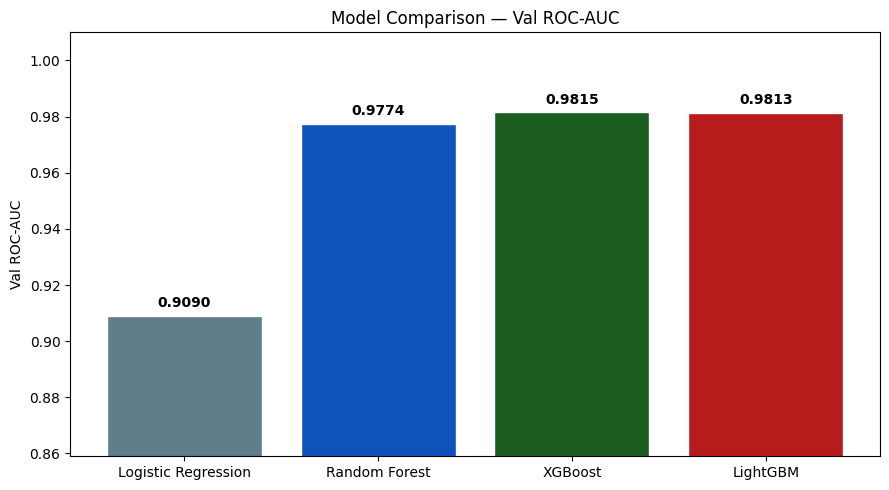

Saved: outputs/08_model_comparison.png


In [12]:
# Model comparison chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#607D8B", "#0F52BA", "#1B5E20", "#B71C1C"]
bars = ax.bar(comparison["Model"], comparison["Val ROC-AUC"],
              color=colors, edgecolor="white")
for bar, val in zip(bars, comparison["Val ROC-AUC"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            "%.4f" % val, ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Val ROC-AUC")
ax.set_title("Model Comparison — Val ROC-AUC")
ax.set_ylim(comparison["Val ROC-AUC"].min() - 0.05, 1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / "08_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/08_model_comparison.png")

## Section 5 — Save

In [13]:
joblib.dump(xgb_model,   OUTPUTS / "xgb_model.pkl")
joblib.dump(lgbm_model,  OUTPUTS / "lgbm_model.pkl")
joblib.dump(study_xgb,   OUTPUTS / "optuna_xgb_study.pkl")
joblib.dump(study_lgbm,  OUTPUTS / "optuna_lgbm_study.pkl")

print("Saved:")
print("  outputs/xgb_model.pkl          (train+val refit, best Optuna params)")
print("  outputs/lgbm_model.pkl         (train+val refit, best Optuna params)")
print("  outputs/optuna_xgb_study.pkl   (%d trials)" % len(study_xgb.trials))
print("  outputs/optuna_lgbm_study.pkl  (%d trials)" % len(study_lgbm.trials))
print()
print("Summary")
print("-" * 55)
print("  XGBoost  best val AUC  : %.4f" % study_xgb.best_value)
print("  XGBoost  test AUC      : %.4f" % xgb_test_auc)
print("  LightGBM best val AUC  : %.4f" % study_lgbm.best_value)
print("  LightGBM test AUC      : %.4f" % lgbm_test_auc)
print("  Best overall model     :",
      "XGBoost" if study_xgb.best_value >= study_lgbm.best_value else "LightGBM")

Saved:
  outputs/xgb_model.pkl          (train+val refit, best Optuna params)
  outputs/lgbm_model.pkl         (train+val refit, best Optuna params)
  outputs/optuna_xgb_study.pkl   (50 trials)
  outputs/optuna_lgbm_study.pkl  (50 trials)

Summary
-------------------------------------------------------
  XGBoost  best val AUC  : 0.9815
  XGBoost  test AUC      : 0.9779
  LightGBM best val AUC  : 0.9818
  LightGBM test AUC      : 0.9789
  Best overall model     : LightGBM
